In [9]:
import qutip
import numpy as np
from qutip import *
import matplotlib.pyplot as plt
from typing import Union
from qutip import basis
import jax.numpy as jnp
import qutip_jax
from scipy import integrate


In [19]:
#parameters
omega_r = 2 * np.pi * 50 #MHz
omega_max = omega_r
omega_c = omega_r #MHz
omega_R = 2.5 * omega_r #MHz
Dta = 2 * np.pi * 1200 #MHz
T_p = 16 * np.pi * Dta/(3 * omega_max**2)
T_c = np.pi/omega_r
tmax = T_c * 2 + T_p
V_dd = 2 * np.pi * 500 #MHz
tau_c = 548
tau_p = 0.131
tau_R = 505
gamma_c = 1/tau_c
gamma_p = 1/tau_p
gamma_R = 1/tau_R

In [20]:
#time list
tlist = np.linspace(0, tmax, 1000)

#control atom states
g = basis(2,0) #|0>     
r = basis(2,1) #|1>

#dagger
g_dag = g.dag()  # <0|
r_dag = r.dag()  # <1|

#target atom states
A = basis(4,0) 
B = basis(4,1)
P = basis(4,2)
R = basis(4,3)

#dagger
A_dag = A.dag()
B_dag = B.dag()
P_dag = P.dag()
R_dag = R.dag()

In [21]:
#control field
def Omega_c(t):
    if 0<=t<T_c:
        return omega_c/2
    elif T_c + T_p<=t<=tmax:
        return omega_c/2
    else:
        return 0

In [22]:
#probe field
def Omega_p(t):
    if T_c<=t<T_c+T_p:
        return (omega_max * (np.sin(np.pi * (t-T_c)/T_p))**2)/2
    else:
        return 0


In [23]:
#integrate 
def integrand(t):
    return (2*Omega_p(t))**2
integral_value, error = integrate.quad(integrand, 0, tmax)

print(f"积分值: {integral_value/(2 * np.pi * Dta):.6f}")
print(f"积分误差: {error:.2e}")


积分值: 1.000000
积分误差: 7.88e-06


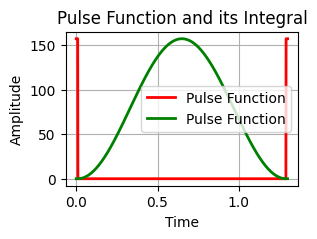

In [24]:
# 可视化函数和积分
t_plot = np.linspace(0, tmax, 1000)
pulse_valuesp = [Omega_p(t) for t in t_plot]
pulse_valuesc = [Omega_c(t) for t in t_plot]
#pulse_values = [Omega_c for t in t_plot]
plt.figure(figsize=(3, 2))
#plt.plot(t_plot, pulse_values, 'b-', linewidth=2, label='Pulse Function')
plt.plot(t_plot, pulse_valuesc, 'r-', linewidth=2, label='Pulse Function')
plt.plot(t_plot, pulse_valuesp, 'g-', linewidth=2, label='Pulse Function')

plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Pulse Function and its Integral')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
#hc = np.array([[0, 0, 0],
#               [0, 0, omega_c/2],
#               [0, omega_c/2, 0]])

#hrr = np.array([[0, 0, 0],
#                [0, 0, 0],
#                [0, 0, 1]])

#hRR = np.array([[0, 0, 0, 0],
#                [0, 0, 0, 0],
#                [0, 0, 0, 0],
#                [0, 0, 0, 1]])
#def ht(t):

#    return Omega_p(t)/2 * (P * A_dag + A * P_dag + P * B_dag + B * P_dag) + Omega_c(t)/2 * (P * R_dag + R * P_dag) - Dta * P * P_dag
#def Hnhermitian(t): 
#    h1 = tensor(hc, Qobj(np.eye(4))) + tensor(Qobj(np.eye(2)), ht(t))
#    h2 = V_dd * tensor(hrr, hRR)
#    h31 = -1j/2 * (L_c.dag() * L_c)
#    h32 = -1j/2 * (L_P.dag() * L_P + L_R.dag() * L_R)
#    h3 = tensor(h31, Qobj(np.eye(4))) + tensor(Qobj(np.eye(2)), h32)
#    return h1 + h2 + h3
#hamiltonian
hc_op = (g * r_dag + r * g_dag)
ht_op = P * A_dag + A * P_dag + P * B_dag + B * P_dag

hrr_op = r * r_dag
hRR_op = R * R_dag
ht_dta = - Dta * P * P_dag
ht_R = omega_R * (P * R_dag + R * P_dag)

Hc_op = tensor(hc_op, Qobj(np.eye(4)))
Ht_op1 = tensor(Qobj(np.eye(2)), ht_op)
Ht_R = tensor(Qobj(np.eye(2)), ht_R)
Ht_dta = tensor(Qobj(np.eye(2)), ht_dta)
HRr = V_dd * tensor(hrr_op, hRR_op)

In [29]:
L_c = np.sqrt(gamma_c) * (g * r_dag)
L_P = np.sqrt(gamma_p) * (A * P_dag + B * P_dag)
L_R = np.sqrt(gamma_R) * (A * R_dag + B * R_dag)

h_L1 = -1j/2 * (L_c.dag() * L_c)
h_L2 = -1j/2 * (L_P.dag() * L_P + L_R.dag() * L_R)

H_L = tensor(h_L1, Qobj(np.eye(4))) + tensor(Qobj(np.eye(2)), h_L2)

In [30]:

Hnhermitian = [H_L, HRr, Ht_dta, Ht_R, [Hc_op,Omega_c], [Ht_op1, Omega_p]]


In [31]:
c_ops = tensor(L_c, Qobj(np.eye(4))) + tensor(Qobj(np.eye(2)), L_P) + tensor(Qobj(np.eye(2)), L_R)

In [32]:
c_ops

Quantum object: dims=[[2, 4], [2, 4]], shape=(8, 8), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0.         0.         2.76289482 0.04449942 0.04271788 0.
  0.         0.        ]
 [0.         0.         2.76289482 0.04449942 0.         0.04271788
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.04271788 0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.04271788]
 [0.         0.         0.         0.         0.         0.
  2.76289482 0.04449942]
 [0.         0.         0.         0.         0.         0.
  2.76289482 0.04449942]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]]

In [38]:
psi_0 = tensor(g,A)
psi_1 = tensor(g,B)
psi_2 = tensor(Qobj(np.eye(2)),A)
psi_3 = tensor(Qobj(np.eye(2)),B)

In [39]:
mc = mcsolve(Hnhermitian, psi_0, tlist, c_ops, [psi_2*psi_2.dag(), psi_3*psi_3.dag()],options={"map":"parallel","progress_bar":"enhanced"})


/home/ubuntu/anaconda3/envs/qutip-newer/lib/python3.10/site-packages/qutip/solver/solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


 Total run time:  15.87s*] Elapsed 15.86s / Remaining 00:00:00:00


In [40]:
print(mc.expect[1][999])


0.9972245074272127


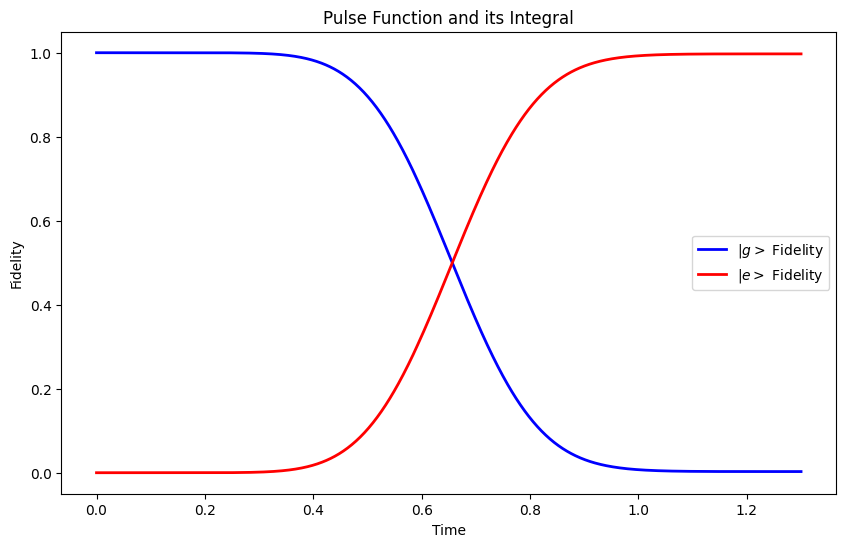

In [43]:
plt.figure(figsize=(10, 6))

plt.plot(tlist,mc.expect[0],'-b',lw=2,label='$|g>$ Fidelity')

plt.plot(tlist,mc.expect[1],'-r',lw=2,label='$|e>$ Fidelity')

plt.xlabel('Time')
plt.ylabel('Fidelity')
plt.title('Pulse Function and its Integral')
plt.legend()
plt.grid(False)
plt.show()
plt.show()